In [1]:
#!/usr/bin/env python3
"""
Multi-compartmental TCR cell intralaminar-type  example

File: TCRil.py

Copyright 2025 NeuroML contributors
Authors: Hua Cheng 
Modified for nRTil by Hua Cheng
"""

from pyneuroml.analysis import generate_current_vs_frequency_curve
from neuroml import NeuroMLDocument
from neuroml.utils import component_factory
from pyneuroml import pynml
from pyneuroml.lems import LEMSSimulation
from pyneuroml.plot.PlotMorphology import plot_2D
import numpy as np
import math
from neuroml import Cell, Species, Segment, SegmentGroup, Point3DWithDiam,NeuroMLDocument
from neuroml.utils import component_factory

INFO:numexpr.utils:NumExpr defaulting to 16 threads.


In [2]:
def create_TCRil_cell():
    nml_cell_doc = NeuroMLDocument(id="TCRil_cell")
    cell = nml_cell_doc.add(Cell,id="TCRil", neuro_lex_id="NLXCELL:091206")  # type neuroml.Cell
    cell.summary()
    cell.info(show_contents=True)
    cell.morphology.info(show_contents=True)

    cell.add_unbranched_segment_group("soma_0")
    diam_soma = 20.0
    diam_axon = 1.6
    diam_dendrite = 1.46
    soma_0 = cell.add_segment(
        prox=[0.0, 0.0, 0.0, diam_soma],
        dist=[0.0, 21.0, 0.0, diam_soma],
        name="Seg0_soma_0",
        group_id="soma_0",
        seg_type="soma"
    )

    soma_1 = cell.add_segment(
        prox=None,
        dist=[-9.179392E-7, 42.0, 0.0, diam_soma],
        name="Seg1_soma_0",
        parent=soma_0,
        group_id="soma_0",
        seg_type="soma"
    )

    # Add axon segments
    cell.add_unbranched_segments(
        [
            [0.0, 21.0, 0.0, diam_axon],
            [9.179392E-7, 0.0, 0.0, diam_axon],
            [-1.7484616E-7, -25.0, 0.0, diam_axon],
        ],
        parent=soma_0,
        fraction_along=0.0,
        group_id="axon_0",
        seg_type="axon"
    )

    cell.add_unbranched_segments(
        [
            [-1.7484616E-7, -25.0, 0.0, diam_axon-0.5],
            [-1.2676315E-6, -50.0, 0.0, diam_axon-0.5],
            [-3.9497368E-6, -75.0, 0.0, diam_axon-0.5],
        ],
        parent=soma_1,
        fraction_along=0.0,
        group_id="axon_1",
        seg_type="axon"
    )
    cell.add_unbranched_segments(
        [
            [-3.9497368E-6, -75.0, 0.0, diam_axon-0.6],
            [-6.6318216E-6, -100.0, 0.0, diam_axon-0.6],
            [9.735456, -123.02701, 0.0, diam_axon-0.6],
        ],
        parent=soma_1,
        fraction_along=0.0,
        group_id="axon_2",
        seg_type="axon"
    )
    cell.add_unbranched_segments(
        [
            [9.735456, -123.02701, 0.0, diam_axon-0.7],
            [19.470907, -146.053, 0.0, diam_axon-0.7],
            [29.206408, -169.08, 0.0, diam_axon-0.7],
        ],
        parent=soma_1,
        fraction_along=0.0,
        group_id="axon_3",
        seg_type="axon"
    )
    cell.add_unbranched_segments(
        [
            [29.206408, -169.08, 0.0, diam_axon-0.8],
            [-6.6318216E-6, -100.0, 0.0, diam_axon-0.8],
            [-9.735474, -123.02701, 0.0, diam_axon-0.8],
        ],
        parent=soma_1,
        fraction_along=0.0,
        group_id="axon_4",
        seg_type="axon"
    )
    cell.add_unbranched_segments(
        [
            [-9.735474, -123.02701, 0.0, diam_axon-0.9],
            [-19.470892, -146.053, 0.0, diam_axon-0.9],
            [-29.206392, -169.08, 0.0, diam_axon-0.9],
        ],
        parent=soma_1,
        fraction_along=0.0,
        group_id="axon_5",
        seg_type="axon"
    )
    
    # Create two balanced hierarchical dendritic structures with 36 dendrites total
    # Each structure will have 18 dendrites arranged in a 3-level hierarchy (6 primary, 6 secondary, 6 tertiary)
    num_dendrites = 72
    radius1 = 50
    radius2 = 250
    y_base = 42.0
    diam_dendrite = 1.46
    # Store dendrite groups for referencing parent segments
    dendrite_groups = {}
    
    # Layer 1: 9 primary dendrites (6 per structure) attached to soma_1
    layer1_count = 9
    for i in range(layer1_count):
        angle = 2 * math.pi * i / layer1_count
        x1 = radius1 * math.cos(angle)
        z1 = radius1 * math.sin(angle)
        x2 = radius2 * math.cos(angle)
        z2 = radius2 * math.sin(angle)

        dend_coords = [
            [0.0, y_base, 0.0, diam_dendrite],
            [x1, y_base + 0.5 * radius1, z1, diam_dendrite],
            [x2, y_base + radius1, z2, diam_dendrite],
        ]
        group = cell.add_unbranched_segments(
            dend_coords,
            parent=soma_1,
            fraction_along=1.0,
            group_id=f"primary_dend_{i}",
            seg_type="dendrite"
        )
        dendrite_groups[f"primary_dend_{i}"] = group

    # Layer 2: 12 secondary dendrites (6 per structure) attached to primary dendrites
    layer2_count = 27
    for i in range(layer2_count):
        # Attach to primary dendrites in a distributed manner
        parent_idx = i * layer1_count // layer2_count
        parent_group = dendrite_groups[f"primary_dend_{parent_idx}"]
        last_segment_id = parent_group.members[-1].segments
        last_segment = cell.get_segment(last_segment_id)
        
        # Get the distal point of the parent segment as the new origin
        parent_x = last_segment.distal.x
        parent_y = last_segment.distal.y
        parent_z = last_segment.distal.z
        
        # Add a subtle twist to the child dendrites
        angle = 2 * math.pi * i / layer2_count + math.pi/60  # Small twist
        twist_angle = (i * 0.02) % (2 * math.pi)  # Minimal twist
        # Make secondary dendrites shorter than primary ones
        x1 = parent_x + radius1 * math.cos(angle) * 0.7
        z1 = parent_z + radius1 * math.sin(angle) * 0.7
        x2 = parent_x + radius2 * math.cos(angle + twist_angle) * 0.7
        z2 = parent_z + radius2 * math.sin(angle + twist_angle) * 0.7

        dend_coords = [
            [parent_x, parent_y, parent_z, diam_dendrite],
            [x1, parent_y + 0.4 * radius1 * 0.7, z1, diam_dendrite],
            [x2, parent_y + 0.8 * radius1 * 0.7, z2, diam_dendrite],
        ]
        group = cell.add_unbranched_segments(
            dend_coords,
            parent=last_segment,
            fraction_along=1.0,
            group_id=f"secondary_dend_{i}",
            seg_type="dendrite"
        )
        dendrite_groups[f"secondary_dend_{i}"] = group

    # Layer 3: 12 tertiary dendrites (6 per structure) attached to secondary dendrites
    layer3_count = 36
    for i in range(layer3_count):
        # Attach to secondary dendrites in a distributed manner
        parent_idx = i * layer2_count // layer3_count
        parent_group = dendrite_groups[f"secondary_dend_{parent_idx}"]
        last_segment_id = parent_group.members[-1].segments
        last_segment = cell.get_segment(last_segment_id)
        
        # Get the distal point of the parent segment as the new origin
        parent_x = last_segment.distal.x
        parent_y = last_segment.distal.y
        parent_z = last_segment.distal.z
        
        # Add a subtle twist to the child dendrites
        angle = 2 * math.pi * i / layer3_count + math.pi/90  # Very small base twist
        twist_angle = (i * 0.01) % (2 * math.pi)  # Minimal twist
        # Make tertiary dendrites shorter than secondary ones
        x1 = parent_x + radius1 * math.cos(angle) * 0.5
        z1 = parent_z + radius1 * math.sin(angle) * 0.5
        x2 = parent_x + radius2 * math.cos(angle + twist_angle) * 0.5
        z2 = parent_z + radius2 * math.sin(angle + twist_angle) * 0.5

        dend_coords = [
            [parent_x, parent_y, parent_z, diam_dendrite],
            [x1, parent_y + 0.3 * radius1 * 0.5, z1, diam_dendrite],
            [x2, parent_y + 0.6 * radius1 * 0.5, z2, diam_dendrite],
        ]
        group = cell.add_unbranched_segments(
            dend_coords,
            parent=last_segment,
            fraction_along=1.0,
            group_id=f"tertiary_dend_{i}",
            seg_type="dendrite"
        )
        dendrite_groups[f"tertiary_dend_{i}"] = group

    # Verify total count
    total_created = layer1_count + layer2_count + layer3_count 
    print(f"Created dendritic tree with {total_created} dendrites (target: {num_dendrites})")

    # color groups for morphology plots
    den_seg_group = cell.get_segment_group("dendrite_group")
    den_seg_group.add("Property", tag="color", value="0.8 0 0")

    ax_seg_group = cell.get_segment_group("axon_group")
    ax_seg_group.add("Property", tag="color", value="0 0.8 0")

    soma_seg_group = cell.get_segment_group("soma_group")
    soma_seg_group.add("Property", tag="color", value="0 0 0.8")


    cell.set_init_memb_potential("-70mV")
    cell.set_resistivity("0.15 kohm_cm")
    cell.set_specific_capacitance("1.3 uF_per_cm2")
    cell.set_spike_thresh("0.0 mV")

    
    # channels
    # ar_axon_group
    cell.add_channel_density(nml_cell_doc,
                             cd_id="ar_axon",
                             cond_density="0.25 mS_per_cm2",
                             ion_channel="ar__m00_25",
                             ion_chan_def_file="ar__m00_25.channel.nml",
                             erev="-35.0 mV",
                             ion="ar",
                             group_id="axon_group")
    # ar_soma_group
    cell.add_channel_density(nml_cell_doc,
                             cd_id="ar_soma",
                             cond_density="0.3 mS_per_cm2",
                             ion_channel="ar__m00_25",
                             ion_chan_def_file="ar__m00_25.channel.nml",
                             erev="-35.0 mV",
                             ion="ar",
                             group_id="soma_group")
    # ar_prox_dends
    cell.add_channel_density(nml_cell_doc,
                             cd_id="ar_dendrite",
                             cond_density="0.5 mS_per_cm2",
                             ion_channel="ar__m00_25",
                             ion_chan_def_file="ar__m00_25.channel.nml",
                             erev="-35.0 mV",
                             ion="ar",
                             group_id="dendrite_group")

    # cal_soma_prox_dends
    cell.add_channel_density(nml_cell_doc,
                             cd_id="cal_soma",
                             cond_density="0.5 mS_per_cm2",
                             ion_channel="cal",
                             ion_chan_def_file="cal.channel.nml",
                             erev="125.0 mV",
                             ion="ca",
                             group_id="soma_group")
    cell.add_channel_density(nml_cell_doc,
                             cd_id="cal_dendrite",
                             cond_density="0.5 mS_per_cm2",
                             ion_channel="cal",
                             ion_chan_def_file="cal.channel.nml",
                             erev="125.0 mV",
                             ion="ca",
                             group_id="dendrite_group")
    # cat_soma_prox_dends
    cell.add_channel_density(nml_cell_doc,
                             cd_id="cat_soma",
                             cond_density="3.0 mS_per_cm2",
                             ion_channel="cat",
                             ion_chan_def_file="cat.channel.nml",
                             erev="125.0 mV",
                             ion="cat",
                             group_id="soma_group")
    cell.add_channel_density(nml_cell_doc,
                             cd_id="cat_dendrite",
                             cond_density="3.0 mS_per_cm2",
                             ion_channel="cat",
                             ion_chan_def_file="cat.channel.nml",
                             erev="125.0 mV",
                             ion="cat",
                             group_id="dendrite_group")
    # k2_soma_prox_dends
    cell.add_channel_density(nml_cell_doc,
                             cd_id="k2_soma",
                             cond_density="2.0 mS_per_cm2",
                             ion_channel="k2",
                             ion_chan_def_file="k2.channel.nml",
                             erev="-95.0 mV",
                             ion="k",
                             group_id="soma_group")
    cell.add_channel_density(nml_cell_doc,
                             cd_id="k2_dendrite",
                             cond_density="2.0 mS_per_cm2",
                             ion_channel="k2",
                             ion_chan_def_file="k2.channel.nml",
                             erev="-95.0 mV",
                             ion="k",
                             group_id="dendrite_group")
    # ka_soma_prox_dends
    cell.add_channel_density(nml_cell_doc,
                             cd_id="ka_soma",
                             cond_density="6.0 mS_per_cm2",
                             ion_channel="ka",
                             ion_chan_def_file="ka.channel.nml",
                             erev="-95.0 mV",
                             ion="k",
                             group_id="soma_group")
    cell.add_channel_density(nml_cell_doc,
                             cd_id="ka_dendrite",
                             cond_density="6.0 mS_per_cm2",
                             ion_channel="ka",
                             ion_chan_def_file="ka.channel.nml",
                             erev="-95.0 mV",
                             ion="k",
                             group_id="dendrite_group")
    # kahp_slower_soma_prox_dends
    cell.add_channel_density(nml_cell_doc,
                             cd_id="kahp_slower_soma",
                             cond_density="0.05 mS_per_cm2",
                            ion_channel="kahp_slower",
                            ion_chan_def_file="kahp_slower.channel.nml",
                            erev="-95.0 mV",
                            ion="k",
                            group_id="soma_group")  
    cell.add_channel_density(nml_cell_doc,
                             cd_id="kahp_slower_dendrite",
                             cond_density="0.05 mS_per_cm2",
                            ion_channel="kahp_slower",
                            ion_chan_def_file="kahp_slower.channel.nml",
                            erev="-95.0 mV",
                            ion="k",
                            group_id="dendrite_group")
    # kc_soma_prox_dends
    cell.add_channel_density(nml_cell_doc,
                             cd_id="kc_soma_group",
                             cond_density="12.0 mS_per_cm2",
                             ion_channel="kc",
                             ion_chan_def_file="kc.channel.nml",
                             erev="-95.0 mV",
                             ion="k",
                             group_id="soma_group")
    cell.add_channel_density(nml_cell_doc,
                             cd_id="kc_dendrite_group",
                             cond_density="12.0 mS_per_cm2",
                             ion_channel="kc",
                             ion_chan_def_file="kc.channel.nml",
                             erev="-95.0 mV",
                             ion="k",
                             group_id="dendrite_group")

    # kdr_soma
    cell.add_channel_density(nml_cell_doc,
                             cd_id="kdr_soma",
                             cond_density="180.0 mS_per_cm2",
                             ion_channel="kdr",
                             ion_chan_def_file="kdr.channel.nml",
                             erev="-95.0 mV",
                             ion="k",
                             group_id="soma_group")
    # kdr_prox_dends
    cell.add_channel_density(nml_cell_doc,
                             cd_id="kdr_dendrite",
                             cond_density="22.5 mS_per_cm2",
                             ion_channel="kdr",
                             ion_chan_def_file="kdr.channel.nml",
                             erev="-95.0 mV",
                             ion="k",
                             group_id="dendrite_group")
    # kdr_axon
    cell.add_channel_density(nml_cell_doc,
                             cd_id="kdr_axon",
                             cond_density="33.75 mS_per_cm2",
                             ion_channel="kdr",
                             ion_chan_def_file="kdr.channel.nml",
                             erev="-95.0 mV",
                             ion="k",
                             group_id="axon_group")

    # km_soma_prox_dends
    cell.add_channel_density(nml_cell_doc,
                             cd_id="km_soma",
                            cond_density="0.5 mS_per_cm2",   
                            ion_channel="km",
                            ion_chan_def_file="km.channel.nml",
                            erev="-95.0 mV",
                            ion="k",
                            group_id="soma_group")
    cell.add_channel_density(nml_cell_doc,
                             cd_id="km_dendrite",
                            cond_density="0.5 mS_per_cm2",   
                            ion_channel="km",
                            ion_chan_def_file="km.channel.nml",
                            erev="-95.0 mV",
                            ion="k",
                            group_id="dendrite_group")
    # naf_tcr_soma_prox_dends
    cell.add_channel_density(nml_cell_doc,
                             cd_id="naf_tcr_soma",
                             cond_density="0.5 mS_per_cm2",
                             ion_channel="naf_tcr__sh_hmin7__sh_m_imin3__sh_m_rmin2_5",
                             ion_chan_def_file="naf_tcr__sh_hmin7__sh_m_imin3__sh_m_rmin2_5.channel.nml",
                             erev="50.0 mV",
                             ion="na",
                             group_id="soma_group")
    cell.add_channel_density(nml_cell_doc,
                             cd_id="naf_tcr_dendrite",
                             cond_density="0.5 mS_per_cm2",
                             ion_channel="naf_tcr__sh_hmin7__sh_m_imin3__sh_m_rmin2_5",
                             ion_chan_def_file="naf_tcr__sh_hmin7__sh_m_imin3__sh_m_rmin2_5.channel.nml",
                             erev="50.0 mV",
                             ion="na",
                             group_id="dendrite_group")

    # napf_tcr_soma_prox_dends
    cell.add_channel_density(nml_cell_doc,
                             cd_id="napf_tcr_soma",
                             cond_density="0.5 mS_per_cm2",
                             ion_channel="napf_tcr__a0__b0__c0__d0__fastNa_shift7",
                             ion_chan_def_file="napf_tcr__a0__b0__c0__d0__fastNa_shift7.channel.nml",
                             erev="50.0 mV",
                             ion="na",
                             group_id="soma_group") 
    cell.add_channel_density(nml_cell_doc,
                             cd_id="napf_tcr_dendrite",
                             cond_density="0.5 mS_per_cm2",
                             ion_channel="napf_tcr__a0__b0__c0__d0__fastNa_shift7",
                             ion_chan_def_file="napf_tcr__a0__b0__c0__d0__fastNa_shift7.channel.nml",
                             erev="50.0 mV",
                             ion="na",
                             group_id="dendrite_group")

    # kc_soma_prox_dends
    cell.add_channel_density(nml_cell_doc,
                             cd_id="kc_soma",
                             cond_density="20.0 mS_per_cm2",
                             ion_channel="kc",
                             ion_chan_def_file="kc.channel.nml",
                             erev="-95.0 mV",
                             ion="k",
                             group_id="soma_group") 
    cell.add_channel_density(nml_cell_doc,
                             cd_id="kc_dendrite",
                             cond_density="20.0 mS_per_cm2",
                             ion_channel="kc",
                             ion_chan_def_file="kc.channel.nml",
                             erev="-95.0 mV",
                             ion="k",
                             group_id="dendrite_group")  

    # kdr_axon
    cell.add_channel_density(nml_cell_doc,
                             cd_id="kdr_axon",
                             cond_density="33.75 mS_per_cm2",
                             ion_channel="kdr",
                             ion_chan_def_file="kdr.channel.nml",
                             erev="-195.0 mV",
                             ion="k",
                             group_id="axon_group")


    # napf_tcr_soma_prox_dends
    cell.add_channel_density(nml_cell_doc,
                             cd_id="napf_tcr_soma",
                             cond_density="0.01 mS_per_cm2",
                             ion_channel="napf_tcr__a0__b0__c0__d0__fastNa_shift7",
                             ion_chan_def_file="napf_tcr__a0__b0__c0__d0__fastNa_shift7.channel.nml",
                             erev="50.0 mV",
                             ion="na",
                             group_id="soma_group")
    cell.add_channel_density(nml_cell_doc,
                             cd_id="napf_tcr_dendrite",
                             cond_density="0.01 mS_per_cm2",
                             ion_channel="napf_tcr__a0__b0__c0__d0__fastNa_shift7",
                             ion_chan_def_file="napf_tcr__a0__b0__c0__d0__fastNa_shift7.channel.nml",
                             erev="50.0 mV",
                             ion="na",
                             group_id="dendrite_group")


    # pas_soma_prox_dends
    cell.add_channel_density(nml_cell_doc, 
                             cd_id="pas_soma",
                             cond_density="1.0 mS_per_cm2",
                             ion_channel="pas",
                             ion_chan_def_file="pas.channel.nml",
                             erev="-70.0 mV",
                             ion="non_specific",
                             group_id="soma_group")
    cell.add_channel_density(nml_cell_doc, 
                             cd_id="pas_dendrite",
                             cond_density="1.0 mS_per_cm2",
                             ion_channel="pas",
                             ion_chan_def_file="pas.channel.nml",
                             erev="-70.0 mV",
                             ion="non_specific",
                             group_id="dendrite_group")
    
    cell.optimise_segment_groups()
    nml_cell_file = "TCRil.cell.nml"
    base_name = nml_cell_file.split('.')[0]
    pynml.write_neuroml2_file(nml_cell_doc, nml_cell_file)
    planes = ['yz', 'xz', 'xy','zx','zy','yx']
    for plane in planes:
        plot_2D(
            nml_cell_file, plane2d=plane, verbose=True ,nogui=True,save_to_file=f"{base_name}_{plane}.png",
            square=False,plot_type="detailed")
    
    nml_doc = pynml.read_neuroml2_file(nml_cell_file)
    generate_current_vs_frequency_curve(
        nml_cell_file,
        nml_doc.cells[0].id,
        start_amp_nA=0.2,
        end_amp_nA=1.0,
        step_nA=0.05,
        pre_zero_pulse=0,
        post_zero_pulse=0,
        dt=0.01,
        analysis_duration=60,
        spike_threshold_mV=0.0,
        plot_voltage_traces=True,
        plot_iv=True,
        save_if_figure_to=f"{base_name}_if.png",
        save_iv_figure_to=f"{base_name}_iv.png",
        simulator='jNeuroML_NEURON',
        title_above_plot=True)
    
    return nml_cell_file



In [3]:
def create_TCRil_network():
    net_doc = NeuroMLDocument(id="network",notes="TCRil net")
    net_doc_fn = "TCRil.net.nml"
    net_doc.add("IncludeType", href=create_TCRil_cell())
    net = net_doc.add("Network", id="TCRil_net", validate=False)
    # Create a population: convenient to create many cells of the same type
    pop = net.add("Population", id="pop0", notes="A population for our cell",
                  component="TCRil", size=1, type="populationList",
                  validate=False)
    pop.add("Instance", id=0, location=component_factory("Location", x=0., y=0., z=0.))
    # Input
    net_doc.add("PulseGenerator",id="pg_nRTil", notes="Simple pulse generator", delay="100ms", duration="100ms", amplitude="0.08nA")
    # net.add("ExplicitInput", target="pop0[0]", input="pg_nRTil")
    net_doc.add("SineGenerator", id="sg_nRTil", notes="Simple sine-generator", phase="2", delay="50ms", duration="200ms",amplitude="1.4nA",period="50ms")
    net.add("ExplicitInput", target="pop0[0]", input="sg_nRTil")
    net_doc.add("RampGenerator", id="rg_nRTil", notes="Simple ramp-generator", delay="50ms", duration="200ms",start_amplitude="0.5nA",finish_amplitude="4nA",baseline_amplitude="0nA")
    # net.add("ExplicitInput", target="pop0[0]", input="rg_nRTil")
    net_doc.add("VoltageClampTriple", id="vClamp_nRTil", notes="Voltage clamp with 3 clamp levels", active="1",delay="50ms", duration="200ms",conditioning_voltage="-70mV",testing_voltage="-50mV",return_voltage="-70mV",simple_series_resistance="1e6ohm")
    # net.add("ExplicitInput", target="pop0[0]", input="vClamp_nRTil")
    pynml.write_neuroml2_file(nml2_doc=net_doc, nml2_file_name=net_doc_fn, validate=True)
    return net_doc_fn



In [4]:
def plot_data(sim_id):
    data_array = np.loadtxt(sim_id + ".dat")
    pynml.generate_plot([data_array[:, 0]], [data_array[:, 1]], "Membrane potential (soma seg 0)", show_plot_already=False, save_figure_to=sim_id + "_seg0_soma0-v.png", xaxis="time (s)", yaxis="membrane potential (V)")
    pynml.generate_plot([data_array[:, 0]], [data_array[:, 2]], "Membrane potential (soma seg 1)", show_plot_already=False, save_figure_to=sim_id + "_seg1_soma0-v.png", xaxis="time (s)", yaxis="membrane potential (V)")
    pynml.generate_plot([data_array[:, 0]], [data_array[:, 3]], "Membrane potential (axon seg 0)", show_plot_already=False, save_figure_to=sim_id + "_seg0_axon0-v.png", xaxis="time (s)", yaxis="membrane potential (V)")
    pynml.generate_plot([data_array[:, 0]], [data_array[:, 4]], "Membrane potential (axon seg 1)", show_plot_already=False, save_figure_to=sim_id + "_seg1_axon0-v.png", xaxis="time (s)", yaxis="membrane potential (V)")
    pynml.generate_plot([data_array[:, 0]], [data_array[:, 3]], "Membrane potential (axon seg 0)", show_plot_already=False, save_figure_to=sim_id + "_seg0_axon1-v.png", xaxis="time (s)", yaxis="membrane potential (V)")
    pynml.generate_plot([data_array[:, 0]], [data_array[:, 4]], "Membrane potential (axon seg 1)", show_plot_already=False, save_figure_to=sim_id + "_seg1_axon1-v.png", xaxis="time (s)", yaxis="membrane potential (V)")
    pynml.generate_plot([data_array[:, 0]], [data_array[:, 3]], "Membrane potential (axon seg 0)", show_plot_already=False, save_figure_to=sim_id + "_seg0_axon2-v.png", xaxis="time (s)", yaxis="membrane potential (V)")
    pynml.generate_plot([data_array[:, 0]], [data_array[:, 4]], "Membrane potential (axon seg 1)", show_plot_already=False, save_figure_to=sim_id + "_seg1_axon2-v.png", xaxis="time (s)", yaxis="membrane potential (V)")
    pynml.generate_plot([data_array[:, 0]], [data_array[:, 3]], "Membrane potential (axon seg 0)", show_plot_already=False, save_figure_to=sim_id + "_seg0_axon3-v.png", xaxis="time (s)", yaxis="membrane potential (V)")
    pynml.generate_plot([data_array[:, 0]], [data_array[:, 4]], "Membrane potential (axon seg 1)", show_plot_already=False, save_figure_to=sim_id + "_seg1_axon3-v.png", xaxis="time (s)", yaxis="membrane potential (V)")
    pynml.generate_plot([data_array[:, 0]], [data_array[:, 3]], "Membrane potential (axon seg 0)", show_plot_already=False, save_figure_to=sim_id + "_seg0_axon4-v.png", xaxis="time (s)", yaxis="membrane potential (V)")
    pynml.generate_plot([data_array[:, 0]], [data_array[:, 4]], "Membrane potential (axon seg 1)", show_plot_already=False, save_figure_to=sim_id + "_seg1_axon4-v.png", xaxis="time (s)", yaxis="membrane potential (V)")
    pynml.generate_plot([data_array[:, 0]], [data_array[:, 3]], "Membrane potential (axon seg 0)", show_plot_already=False, save_figure_to=sim_id + "_seg0_axon5-v.png", xaxis="time (s)", yaxis="membrane potential (V)")
    pynml.generate_plot([data_array[:, 0]], [data_array[:, 4]], "Membrane potential (axon seg 1)", show_plot_already=False, save_figure_to=sim_id + "_seg1_axon5-v.png", xaxis="time (s)", yaxis="membrane potential (V)")
    pynml.generate_plot([data_array[:, 0]], [data_array[:, 3]], "Membrane potential (dend seg 0)", show_plot_already=False, save_figure_to=sim_id + "_seg0_dend0-v.png", xaxis="time (s)", yaxis="membrane potential (V)")
    pynml.generate_plot([data_array[:, 0]], [data_array[:, 4]], "Membrane potential (dend seg 1)", show_plot_already=False, save_figure_to=sim_id + "_seg1_dend0-v.png", xaxis="time (s)", yaxis="membrane potential (V)")
    pynml.generate_plot([data_array[:, 0]], [data_array[:, 3]], "Membrane potential (dend seg 0)", show_plot_already=False, save_figure_to=sim_id + "_seg0_dend35-v.png", xaxis="time (s)", yaxis="membrane potential (V)")
    pynml.generate_plot([data_array[:, 0]], [data_array[:, 4]], "Membrane potential (dend seg 1)", show_plot_already=False, save_figure_to=sim_id + "_seg1_dend35-v.png", xaxis="time (s)", yaxis="membrane potential (V)")



In [5]:
def main():
    # Simulation bits
    sim_id = "TCRil_sim"
    simulation = LEMSSimulation(sim_id=sim_id, duration=200, dt=0.01, simulation_seed=123)
    # Include the NeuroML model file
    simulation.include_neuroml2_file(create_TCRil_network())
    # Assign target for the simulation
    simulation.assign_simulation_target("TCRil_net")

    # Recording information from the simulation
    simulation.create_output_file(id="output0", file_name=sim_id + ".dat")
    simulation.add_column_to_output_file("output0", column_id="pop0_0_v", quantity="pop0[0]/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_soma_0",quantity="pop0/0/TCR/0/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_soma_0",quantity="pop0/0/TCR/1/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_axon_0",quantity="pop0/0/TCR/2/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_axon_0",quantity="pop0/0/TCR/3/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_axon_1",quantity="pop0/0/TCR/4/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_axon_1",quantity="pop0/0/TCR/5/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_axon_2",quantity="pop0/0/TCR/6/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_axon_2",quantity="pop0/0/TCR/7/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_axon_3",quantity="pop0/0/TCR/8/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_axon_3",quantity="pop0/0/TCR/9/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_axon_4",quantity="pop0/0/TCR/10/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_axon_4",quantity="pop0/0/TCR/11/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_axon_5",quantity="pop0/0/TCR/12/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_axon_5",quantity="pop0/0/TCR/13/v")
    # Simplified recording for dendrites - just record a few representative ones
    # First structure primary dendrites
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_primary_dend_1_0",quantity="pop0/0/TCR/14/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_primary_dend_1_1",quantity="pop0/0/TCR/15/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_primary_dend_1_2",quantity="pop0/0/TCR/16/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_primary_dend_1_3",quantity="pop0/0/TCR/17/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_primary_dend_1_4",quantity="pop0/0/TCR/18/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_primary_dend_1_5",quantity="pop0/0/TCR/19/v")
    # First structure secondary dendrites
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_secondary_dend_1_0",quantity="pop0/0/TCR/20/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_secondary_dend_1_1",quantity="pop0/0/TCR/21/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_secondary_dend_1_2",quantity="pop0/0/TCR/22/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_secondary_dend_1_3",quantity="pop0/0/TCR/23/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_secondary_dend_1_4",quantity="pop0/0/TCR/24/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_secondary_dend_1_5",quantity="pop0/0/TCR/25/v")
    # First structure tertiary dendrites
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_tertiary_dend_1_0",quantity="pop0/0/TCR/26/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_tertiary_dend_1_1",quantity="pop0/0/TCR/27/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_tertiary_dend_1_2",quantity="pop0/0/TCR/28/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_tertiary_dend_1_3",quantity="pop0/0/TCR/29/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_tertiary_dend_1_4",quantity="pop0/0/TCR/30/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_tertiary_dend_1_5",quantity="pop0/0/TCR/31/v")
    # Second structure primary dendrites
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_primary_dend_2_0",quantity="pop0/0/TCR/32/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_primary_dend_2_1",quantity="pop0/0/TCR/33/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_primary_dend_2_2",quantity="pop0/0/TCR/34/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_primary_dend_2_3",quantity="pop0/0/TCR/35/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_primary_dend_2_4",quantity="pop0/0/TCR/36/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_primary_dend_2_5",quantity="pop0/0/TCR/37/v")
    # Second structure secondary dendrites
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_secondary_dend_2_0",quantity="pop0/0/TCR/38/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_secondary_dend_2_1",quantity="pop0/0/TCR/39/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_secondary_dend_2_2",quantity="pop0/0/TCR/40/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_secondary_dend_2_3",quantity="pop0/0/TCR/41/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_secondary_dend_2_4",quantity="pop0/0/TCR/42/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_secondary_dend_2_5",quantity="pop0/0/TCR/43/v")
    # Second structure tertiary dendrites
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_tertiary_dend_2_0",quantity="pop0/0/TCR/44/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_tertiary_dend_2_1",quantity="pop0/0/TCR/45/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_tertiary_dend_2_2",quantity="pop0/0/TCR/46/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_tertiary_dend_2_3",quantity="pop0/0/TCR/47/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_tertiary_dend_2_4",quantity="pop0/0/TCR/48/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_tertiary_dend_2_5",quantity="pop0/0/TCR/49/v")
    sim_file = simulation.save_to_file()

    # Run the simulation using the NEURON simulator
    pynml.run_lems_with_jneuroml_neuron(sim_file, max_memory="24G", nogui=True,plot=False, skip_run=False)
    # Plot the data
    plot_data(sim_id)



*********** Summary (TCRil) ************
* Notes: None


*********** Morphology summary (TCRil) ************
* Segments: 0
* SegmentGroups: 2

* SegmentGroup: soma_group; 0 members, 0 included groups, 0 segments
* SegmentGroup: all; 0 members, 0 included groups, 0 segments
*******************************************************


*********** Biophys summary (TCRil) ************
*******************************************************



pyNeuroML >>> 20:27:13 - INFO - Executing: (java -Xmx400M  -jar  "/home/leo520/pynml/.pixi/envs/default/lib/python3.12/site-packages/pyneuroml/utils/./../lib/jNeuroML-0.14.0-jar-with-dependencies.jar" -validate TCRil.cell.nml ) in directory: .


Created dendritic tree with 72 dendrites (target: 72)


pyNeuroML >>> 20:27:14 - ERROR - *** Problem running last command: Command 'java -Xmx400M  -jar  "/home/leo520/pynml/.pixi/envs/default/lib/python3.12/site-packages/pyneuroml/utils/./../lib/jNeuroML-0.14.0-jar-with-dependencies.jar" -validate TCRil.cell.nml ' returned non-zero exit status 1.
pyNeuroML >>> 20:27:14 - INFO - Loading NeuroML2 file: TCRil.cell.nml
pyNeuroML >>> 20:27:14 - INFO - 
Seg Seg0_soma_0, id: 0 has proximal: (0.0, 0.0, 0.0), diam 20.0um, distal: (0.0, 21.0, 0.0), diam 20.0um (width: 20.0, min_width: 0.8), color: g
pyNeuroML >>> 20:27:14 - INFO - 
Seg Seg1_soma_0, id: 1 has proximal: (0.0, 21.0, 0.0), diam 20.0um, distal: (-9.179392e-07, 42.0, 0.0), diam 20.0um (width: 20.0, min_width: 0.8), color: g
pyNeuroML >>> 20:27:14 - INFO - 
Seg Seg0_axon_0, id: 2 has proximal: (0.0, 21.0, 0.0), diam 1.6um, distal: (9.179392e-07, 0.0, 0.0), diam 1.6um (width: 1.6, min_width: 0.8), color: r
pyNeuroML >>> 20:27:14 - INFO - 
Seg Seg1_axon_0, id: 3 has proximal: (9.179392e-07, 0

####################################################################
 jNeuroML >>   jNeuroML v0.14.0
 jNeuroML >>  Validating: /home/leo520/cortico-thalamo-cortico-loop-framework/notebooks/Sim_TCRil/TCRil.cell.nml
 jNeuroML >>  Valid against schema
 jNeuroML >>    Test: 10025 (Ion channel in channelDensity should exist) failed! ... Ion channel: ar__m00_25 in ar_axon not found!
 jNeuroML >>    Test: 10025 (Ion channel in channelDensity should exist) failed! ... Ion channel: ar__m00_25 in ar_soma not found!
 jNeuroML >>    Test: 10025 (Ion channel in channelDensity should exist) failed! ... Ion channel: ar__m00_25 in ar_dendrite not found!
 jNeuroML >>    Test: 10025 (Ion channel in channelDensity should exist) failed! ... Ion channel: cal in cal_soma not found!
 jNeuroML >>    Test: 10025 (Ion channel in channelDensity should exist) failed! ... Ion channel: cal in cal_dendrite not found!
 jNeuroML >>    Test: 10025 (Ion channel in channelDensity should exist) failed! ... Ion channel: ca

...

Saved image on plane zy to /home/leo520/cortico-thalamo-cortico-loop-framework/notebooks/Sim_TCRil/TCRil_zy.png of plot: TCRil_cell
Plotting TCRil.cell.nml
Population: dummy_population_TCRil has 0 positioned cells of type: TCRil
Extent x: 0.0 -> 21.0
Extent x: 0.0 -> 42.0
Extent x: 0.0 -> 42.0
Extent x: -25.0 -> 42.0
Extent x: -50.0 -> 42.0
Extent x: -75.0 -> 42.0
Extent x: -100.0 -> 42.0
Extent x: -123.02701 -> 42.0
Extent x: -146.053 -> 42.0
Extent x: -169.08 -> 42.0
Extent x: -169.08 -> 42.0
Extent x: -169.08 -> 42.0
Extent x: -169.08 -> 42.0
Extent x: -169.08 -> 42.0
Extent x: -169.08 -> 67.0
Extent x: -169.08 -> 92.0
Extent x: -169.08 -> 92.0
Extent x: -169.08 -> 92.0
Extent x: -169.08 -> 92.0
Extent x: -169.08 -> 92.0
Extent x: -169.08 -> 92.0
Extent x: -169.08 -> 92.0
Extent x: -169.08 -> 92.0
Extent x: -169.08 -> 92.0
Extent x: -169.08 -> 92.0
Extent x: -169.08 -> 92.0
Extent x: -169.08 -> 92.0
Extent x: -169.08 -> 92.0
Extent x: -169.08 -> 92.0
Extent x: -169.08 -> 92.0
Extent

pyNeuroML >>> 20:27:17 - INFO - Loading NeuroML2 file: TCRil.cell.nml
pyNeuroML >>> 20:27:17 - INFO - Running generate_current_vs_frequency_curve() on TCRil.cell.nml (/home/leo520/cortico-thalamo-cortico-loop-framework/notebooks/Sim_TCRil/TCRil.cell.nml)
pyNeuroML >>> 20:27:17 - INFO - Loading NeuroML2 file: /home/leo520/cortico-thalamo-cortico-loop-framework/notebooks/Sim_TCRil/TCRil.cell.nml
pyNeuroML >>> 20:27:17 - INFO - Loading NeuroML2 file: /home/leo520/cortico-thalamo-cortico-loop-framework/notebooks/Sim_TCRil/ar__m00_25.channel.nml
pyNeuroML >>> 20:27:17 - CRITICAL - Unable to find file: /home/leo520/cortico-thalamo-cortico-loop-framework/notebooks/Sim_TCRil/ar__m00_25.channel.nml!


Saved image on plane yx to /home/leo520/cortico-thalamo-cortico-loop-framework/notebooks/Sim_TCRil/TCRil_yx.png of plot: TCRil_cell


SystemExit: 13

/home/leo520/pynml/.pixi/envs/default/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3707: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


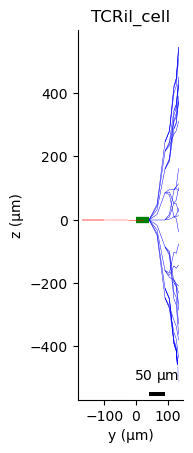

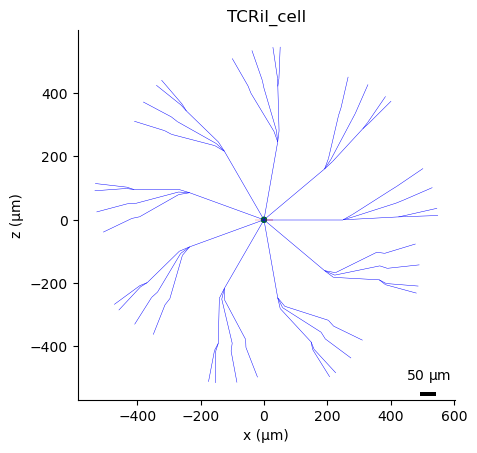

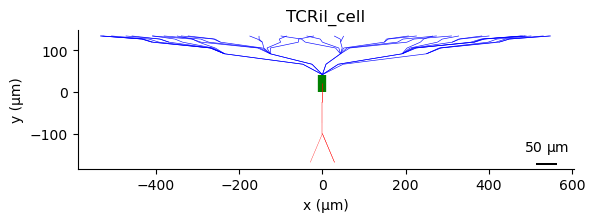

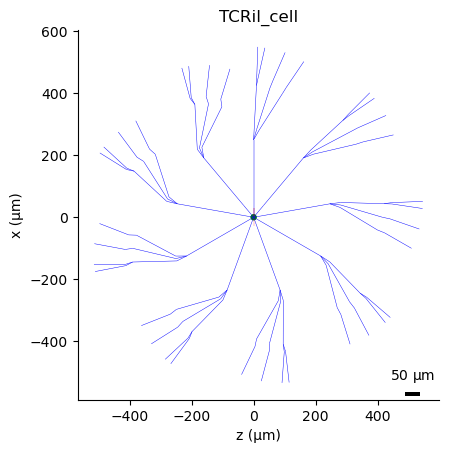

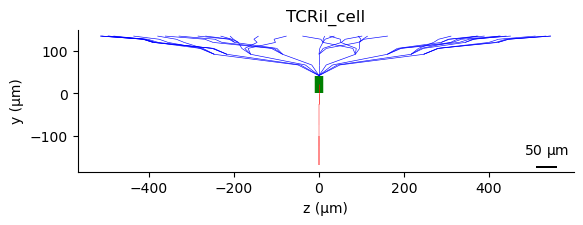

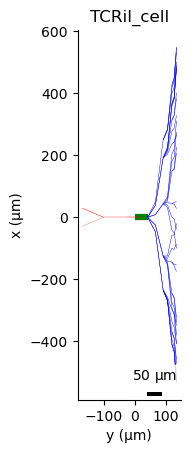

In [6]:
if __name__ == "__main__":
    main()